In [2]:
# Imports and pip installations (if needed)
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Part 1: Load the dataset

In [3]:
# Load the given datasets
chronic_kidney_disease_numerical = os.path.join(os.getcwd(), "chronic_kidney_disease_numerical.csv")
chronic_kidney_disease_categorical = os.path.join(os.getcwd(), "chronic_kidney_disease_categorical.csv")
df_numerical = pd.read_csv(chronic_kidney_disease_numerical)
df_categorical = pd.read_csv(chronic_kidney_disease_categorical)

# Print the data
df_numerical.head()
df_categorical.head()

,unique_id,al,su,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,Target
0,224481,3.0,NaN,NaN,NaN,notpresent,notpresent,yes,yes,no,good,yes,no,ckd
1,992643,0.0,0.0,NaN,NaN,notpresent,notpresent,no,no,no,good,no,no,notckd
2,308740,1.0,0.0,abnormal,abnormal,notpresent,notpresent,yes,no,no,good,yes,no,ckd
3,450314,1.0,0.0,NaN,normal,notpresent,notpresent,no,no,no,good,no,yes,ckd
4,881763,0.0,0.0,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd


# Part 2: Analyze the Dataset

Refer to this: https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

Explain what the each data is in your own words. What are the features and labels? Are the features in the given datasets : categorical, numerical or both? Give 3 examples of categorical and numerical columns each (if they exist)

Answer: 
First, let us look at and analyze the data set titled chronic_kidney_disease_numerical or df_numerical. This dataframe's unique identifier or label is unique_id whilst the features are the rest of the columns: age, bp, bgr, bu, sc, sod, pot, hemo, pcv, wbcc, rbcc. In this case the features and label both are numerical since they all have specific float or int values. The dataset also has missing values which means it will have NaN data types. 
Next, lets's look at chronic_kidney_disease_categorical or df_cetgorical. This dataset's unique identifier or label is unique_id with features: al, su, rbc, pc, pcc, ba, htn, dm, cad, appet, pe, ane, and Target. Here the columns with nuemrical data (int or float data type) are unique_id, al, and su. The rest of the columns all contain categorical data that seem to be of string data types. This dataset too has missing values that seem to be of type null and NaN. 
These datasets look like they could be used for supervised learning ML models where they can either be applied in a classification context (in the case of the categorical dataset) and regression context (in the case of the nummerical dataset).

# Part 3: Data Preprocessing

A fundamental skill in Machine Learning is mastering the art of data cleaning and preprocessing. In this assignment, you will learn and apply essential data cleaning techniques to transform a raw dataset into a clean, ready-to-use form which you can use for regression or classification tasks. By the end of this assignment, you'll have a fully clean dataset and a solid foundation in preparing data for various machine learning models.

## Part 3.1 : Drop Duplicate rows

Let's start by checking if the given datasets have any duplicate rows (same Unique Id). Use pandas to identify and remove these duplicate rows from the given dataset

In [4]:
# For the numerical dataset, check if there are duplicate rows in the dataset. If yes, print total number of duplicate rows
duplicates = df_numerical.duplicated(subset='unique_id', keep=False)
duplicate_rows = df_numerical[duplicates]
print(duplicate_rows)

# Drop these duplicate rows
df_numerical.drop_duplicates(duplicate_rows)

# Repeat the same for categorical dataset. Print the duplicate rows and drop them
duplicates2 = df_categorical.duplicated(subset='unique_id', keep=False)
duplicate_rows2 = df_categorical[duplicates2]
print(duplicate_rows2)
df_categorical.drop_duplicates(duplicate_rows2)


     unique_id   age     bp    bgr     bu   sc    sod  pot  hemo   pcv  \
1       938027  43.0   60.0  108.0   25.0  1.0  144.0  5.0  17.8  43.0   
4       240975  47.0   80.0   95.0   35.0  0.9  140.0  4.1   NaN   NaN   
15      224481  54.0   60.0  125.0   21.0  1.3  137.0  3.4  15.0  46.0   
35      431871  57.0   60.0  132.0   18.0  1.1  150.0  4.7  15.4  42.0   
42      441170  79.0   80.0  111.0   44.0  1.2  146.0  3.6  16.3  40.0   
53      261137  35.0   60.0  105.0   39.0  0.5  135.0  3.9  14.7  43.0   
54      721270  58.0   70.0  102.0   48.0  1.2  139.0  4.3  15.0  40.0   
61      872034  70.0   90.0  184.0   98.6  3.3  138.0  3.9   5.8   NaN   
78      501321   4.0    NaN   99.0   23.0  0.6  138.0  4.4  12.0  34.0   
79      283427  55.0   80.0  140.0   49.0  0.5  150.0  4.9  15.7  47.0   
81      302906  59.0  100.0    NaN   96.0  6.4    NaN  NaN   6.6   NaN   
98      708255   3.0    NaN    NaN   22.0  0.7    NaN  NaN  10.7  34.0   
107     872034  70.0   90.0  184.0   9

,unique_id,al,su,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,Target
0,224481,3.0,NaN,NaN,NaN,notpresent,notpresent,yes,yes,no,good,yes,no,ckd
1,992643,0.0,0.0,NaN,NaN,notpresent,notpresent,no,no,no,good,no,no,notckd
2,308740,1.0,0.0,abnormal,abnormal,notpresent,notpresent,yes,no,no,good,yes,no,ckd
3,450314,1.0,0.0,NaN,normal,notpresent,notpresent,no,no,no,good,no,yes,ckd
4,881763,0.0,0.0,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,789906,0.0,0.0,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
397,490253,0.0,0.0,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
398,492993,3.0,0.0,NaN,normal,notpresent,notpresent,yes,no,no,good,no,yes,ckd
399,273038,0.0,0.0,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd


## Part 3.2: Combine two differents datasets

A good skill to have is to know how to combine 2 different datasets.

Are all the unique ids are present in both datasets? Why do you think so? If not, what do the rows that are missing from one of the datasets look like in the combined table?

Answer:

In [5]:
# Merge the two given numerical and categorical datasets based on their unique_ID.
df = pd.merge(df_numerical, df_categorical, on='unique_id')

#Print the combined dataset
print(df.head(10))

   unique_id   age    bp    bgr     bu   sc    sod  pot  hemo   pcv  ...  \
0     203694  38.0  80.0   99.0   19.0  0.5  147.0  3.5  13.6  44.0  ...   
1     938027  43.0  60.0  108.0   25.0  1.0  144.0  5.0  17.8  43.0  ...   
2     938027  43.0  60.0  108.0   25.0  1.0  144.0  5.0  17.8  43.0  ...   
3     421471  37.0  60.0  111.0   35.0  0.8  135.0  4.1  16.2  50.0  ...   
4     764115  70.0  90.0  144.0  125.0  4.0  136.0  4.6  12.0  37.0  ...   
5     240975  47.0  80.0   95.0   35.0  0.9  140.0  4.1   NaN   NaN  ...   
6     240975  47.0  80.0   95.0   35.0  0.9  140.0  4.1   NaN   NaN  ...   
7     992643  35.0  70.0   82.0   36.0  1.1  150.0  3.5  14.5  52.0  ...   
8     573400  60.0  80.0    NaN    NaN  NaN    NaN  NaN   NaN   NaN  ...   
9     109053  64.0  60.0  106.0   27.0  0.7  150.0  3.3  14.4  42.0  ...   

       pc         pcc          ba  htn   dm cad appet   pe ane  Target  
0  normal  notpresent  notpresent   no   no  no  good   no  no  notckd  
1  normal  notpre

## Part 3.3: Rows with Missing values

Removing missing values from a dataset is important for classification because it ensures the model is trained on complete and accurate data, leading to better performance and reliable predictions. Incomplete data can introduce bias and errors, negatively impacting the model's effectiveness.

In [6]:
# Calculate the percentage of rows that contain atleast one missing value
nan_count = np.sum(df.isnull(), axis = 0)
nan_detected = (nan_count / df.shape[0])*100

# Print %
print(nan_detected)

# Drop these rows from the dataset
df = df.dropna()

# Print the Dataset
print(df.head(10))

unique_id     0.000000
age           1.659751
bp            4.356846
bgr           9.958506
bu            3.941909
sc            3.526971
sod          20.124481
pot          20.331950
hemo         13.692946
pcv          19.709544
wbcc         28.423237
rbcc         34.232365
al           11.618257
su           12.863071
rbc          38.174274
pc           16.182573
pcc           0.622407
ba            0.622407
htn           0.414938
dm            0.414938
cad           0.414938
appet         0.207469
pe            0.207469
ane           0.207469
Target        0.000000
dtype: float64
    unique_id   age    bp    bgr    bu   sc    sod  pot  hemo   pcv  ...  \
0      203694  38.0  80.0   99.0  19.0  0.5  147.0  3.5  13.6  44.0  ...   
1      938027  43.0  60.0  108.0  25.0  1.0  144.0  5.0  17.8  43.0  ...   
2      938027  43.0  60.0  108.0  25.0  1.0  144.0  5.0  17.8  43.0  ...   
3      421471  37.0  60.0  111.0  35.0  0.8  135.0  4.1  16.2  50.0  ...   
9      109053  64.0  60.0  106

## Part 3.4: Sort the dataset according to the Labels

In [7]:
# Sort the dataset according to the values in 'Target' column. Make sure reset the indices after sorting
df = df.sort_values(by = 'Target')

# Print the dataset
print(df.head(10))

     unique_id   age     bp    bgr     bu    sc    sod  pot  hemo   pcv  ...  \
480     474407  21.0   90.0  107.0   40.0   1.7  125.0  3.5   8.3  23.0  ...   
105     137148  73.0  100.0  295.0   90.0   5.6  140.0  2.9   9.2  30.0  ...   
118     484175  53.0   90.0   70.0  107.0   7.2  114.0  3.7   9.5  29.0  ...   
397     337834  48.0   70.0  117.0   56.0   3.8  111.0  2.5  11.2  32.0  ...   
396     337834  48.0   70.0  117.0   56.0   3.8  111.0  2.5  11.2  32.0  ...   
390     343710  61.0   80.0  173.0  148.0   3.9  135.0  5.2   7.7  24.0  ...   
150     602404  55.0   90.0  273.0  235.0  14.2  132.0  3.4   8.3  22.0  ...   
152     514721  56.0   90.0  129.0  107.0   6.7  131.0  4.8   9.1  29.0  ...   
372     532520  60.0   90.0  105.0   53.0   2.3  136.0  5.2  11.1  33.0  ...   
369     566924  49.0  100.0  129.0  158.0  11.8  122.0  3.2   8.1  24.0  ...   

           pc         pcc          ba  htn   dm  cad appet   pe  ane Target  
480  abnormal     present     present   n

## Part 3.5: Encoding Categorical data

In this step, we identify and process the categorical columns in the sorted dataset. We map each unique value in these columns to separate "dummy" columns.

For example, the column 'rbc' will be transformed into two columns 'rbc_normal' and 'rbc_abnormal'. If a row's value in 'rbc' is 'normal', the 'rbc_normal' column will be set to 1 and 'rbc_abnormal' will be set to 0.


**Note: Find a correct pandas function to do this **

In [8]:
# Write code here
categorical_columns = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'Target']
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Print the dataset
print(df.head(10))

     unique_id   age     bp    bgr     bu    sc    sod  pot  hemo   pcv  ...  \
480     474407  21.0   90.0  107.0   40.0   1.7  125.0  3.5   8.3  23.0  ...   
105     137148  73.0  100.0  295.0   90.0   5.6  140.0  2.9   9.2  30.0  ...   
118     484175  53.0   90.0   70.0  107.0   7.2  114.0  3.7   9.5  29.0  ...   
397     337834  48.0   70.0  117.0   56.0   3.8  111.0  2.5  11.2  32.0  ...   
396     337834  48.0   70.0  117.0   56.0   3.8  111.0  2.5  11.2  32.0  ...   
390     343710  61.0   80.0  173.0  148.0   3.9  135.0  5.2   7.7  24.0  ...   
150     602404  55.0   90.0  273.0  235.0  14.2  132.0  3.4   8.3  22.0  ...   
152     514721  56.0   90.0  129.0  107.0   6.7  131.0  4.8   9.1  29.0  ...   
372     532520  60.0   90.0  105.0   53.0   2.3  136.0  5.2  11.1  33.0  ...   
369     566924  49.0  100.0  129.0  158.0  11.8  122.0  3.2   8.1  24.0  ...   

     pc_normal  pcc_present  ba_present  htn_yes  dm_yes  cad_yes  appet_poor  \
480      False         True        Tru

In the example we went through above, another solution is to have a single column for the binary variable. In the downstream modeling would this be equivalent? What effect would this have if the categorical variable could take more than 2 values? For example, let's say we have a categorical feature that is "type of condiment" that can take 5 separate values and we are trying to predict the rating of a particular sandwich.

## Part 3.6 : Remove Outliers from Numerical Columns

Outliers can disproportionately influence the fit of a regression model, potentially leading to a model that does not generalize well therefore it is important that we remove outliers from the numerical columns of the dataset.

For this dataset, we define an outlier to be 3 times the standard deviation from the mean. Drop these outliers from the dataset

In [9]:
# Remove outliers
numerical_columns = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
for col in numerical_columns:
    mean = np.mean(df[col])
    std_dev = np.std(df[col])
    q3 = mean + 3 * std_dev
    q1 = mean - 3 * std_dev
    mask = (df[col] <= q3) & (df[col] >= q1)
    df = df[mask]

# Print the dataset
print(df.head(10))

     unique_id   age     bp    bgr     bu   sc    sod  pot  hemo   pcv  ...  \
105     137148  73.0  100.0  295.0   90.0  5.6  140.0  2.9   9.2  30.0  ...   
152     514721  56.0   90.0  129.0  107.0  6.7  131.0  4.8   9.1  29.0  ...   
372     532520  60.0   90.0  105.0   53.0  2.3  136.0  5.2  11.1  33.0  ...   
363     546225  46.0   60.0  163.0   92.0  3.3  141.0  4.0   9.8  28.0  ...   
349     621332  59.0   80.0  303.0   35.0  1.3  122.0  3.5  10.4  35.0  ...   
262     397388  63.0  100.0  280.0   35.0  3.2  143.0  3.5  13.0  40.0  ...   
288     438182  73.0   80.0  253.0  142.0  4.6  138.0  5.8  10.5  33.0  ...   
239     923613  64.0   60.0  239.0   58.0  4.3  137.0  5.4   9.5  29.0  ...   
298     955830  55.0   80.0  214.0   73.0  3.9  137.0  4.9  10.9  34.0  ...   
228     995177  69.0   70.0  214.0   96.0  6.3  120.0  3.9   9.4  28.0  ...   

     pc_normal  pcc_present  ba_present  htn_yes  dm_yes  cad_yes  appet_poor  \
105      False         True       False     True 

## Part 3.7 : Normalize the Numerical Columns

Normalizing numerical attributes ensures that all features contribute equally to the model by scaling them to a consistent range, which improves model performance and convergence. It prevents features with larger scales from disproportionately influencing the model's learning process.

In [10]:
# Normalize the all Numerical Attributes in the dataset.
min_max_scaling = MinMaxScaler()
df[numerical_columns] = min_max_scaling.fit_transform(df[numerical_columns])

# Print the dataset
print(df.head(10))

     unique_id       age    bp       bgr        bu        sc       sod  \
105     137148  0.897059  1.00  0.965665  0.606061  0.825397  0.666667   
152     514721  0.647059  0.75  0.253219  0.734848  1.000000  0.366667   
372     532520  0.705882  0.75  0.150215  0.325758  0.301587  0.533333   
363     546225  0.500000  0.00  0.399142  0.621212  0.460317  0.700000   
349     621332  0.691176  0.50  1.000000  0.189394  0.142857  0.066667   
262     397388  0.750000  1.00  0.901288  0.189394  0.444444  0.766667   
288     438182  0.897059  0.50  0.785408  1.000000  0.666667  0.600000   
239     923613  0.764706  0.00  0.725322  0.363636  0.619048  0.566667   
298     955830  0.632353  0.50  0.618026  0.477273  0.555556  0.566667   
228     995177  0.838235  0.25  0.618026  0.651515  0.936508  0.000000   

          pot      hemo       pcv  ...  pc_normal  pcc_present  ba_present  \
105  0.000000  0.011494  0.076923  ...      False         True       False   
152  0.655172  0.000000  0.03

## Part 3.8: Remove Unnecessary columns

Are there any columns in this dataset which are not appropriate for modeling and predictions? Which column(s)? Justify their exclusion and remove them

Answer: to see which columns are unnecessary, I will use a correlation matrix. However, just by looking at the dataset and all its columns, I think that appetite might not necessarily help in predicting whether someone would get chronic kindey disease. Moreover, it might be helpful to eliminate the columns that indicate a good condition for so and so metric as that won't help in the prediction as we're trying to find signs and symptoms of abnormalities (vs normality). For example, cad_no, htn_no etc...

In [12]:
#correlation matrix
correlation_matrix = df.corr()
print(correlation_matrix)

               unique_id       age        bp       bgr        bu        sc  \
unique_id       1.000000  0.036991 -0.017207 -0.044774  0.060068  0.090956   
age             0.036991  1.000000  0.104995  0.320528  0.240022  0.285043   
bp             -0.017207  0.104995  1.000000  0.213450  0.038696  0.162152   
bgr            -0.044774  0.320528  0.213450  1.000000  0.419580  0.609736   
bu              0.060068  0.240022  0.038696  0.419580  1.000000  0.713371   
sc              0.090956  0.285043  0.162152  0.609736  0.713371  1.000000   
sod            -0.108288  0.054356 -0.045794 -0.237332 -0.260810 -0.359886   
pot             0.053301 -0.081399 -0.038705 -0.003001  0.053829  0.031656   
hemo           -0.079333 -0.181987 -0.032709 -0.530835 -0.482271 -0.629359   
pcv            -0.003249 -0.236100 -0.061075 -0.527775 -0.462175 -0.641237   
wbcc            0.127210  0.182732 -0.088583  0.164787  0.128180  0.185975   
rbcc           -0.028912 -0.225067 -0.108338 -0.499926 -0.388534

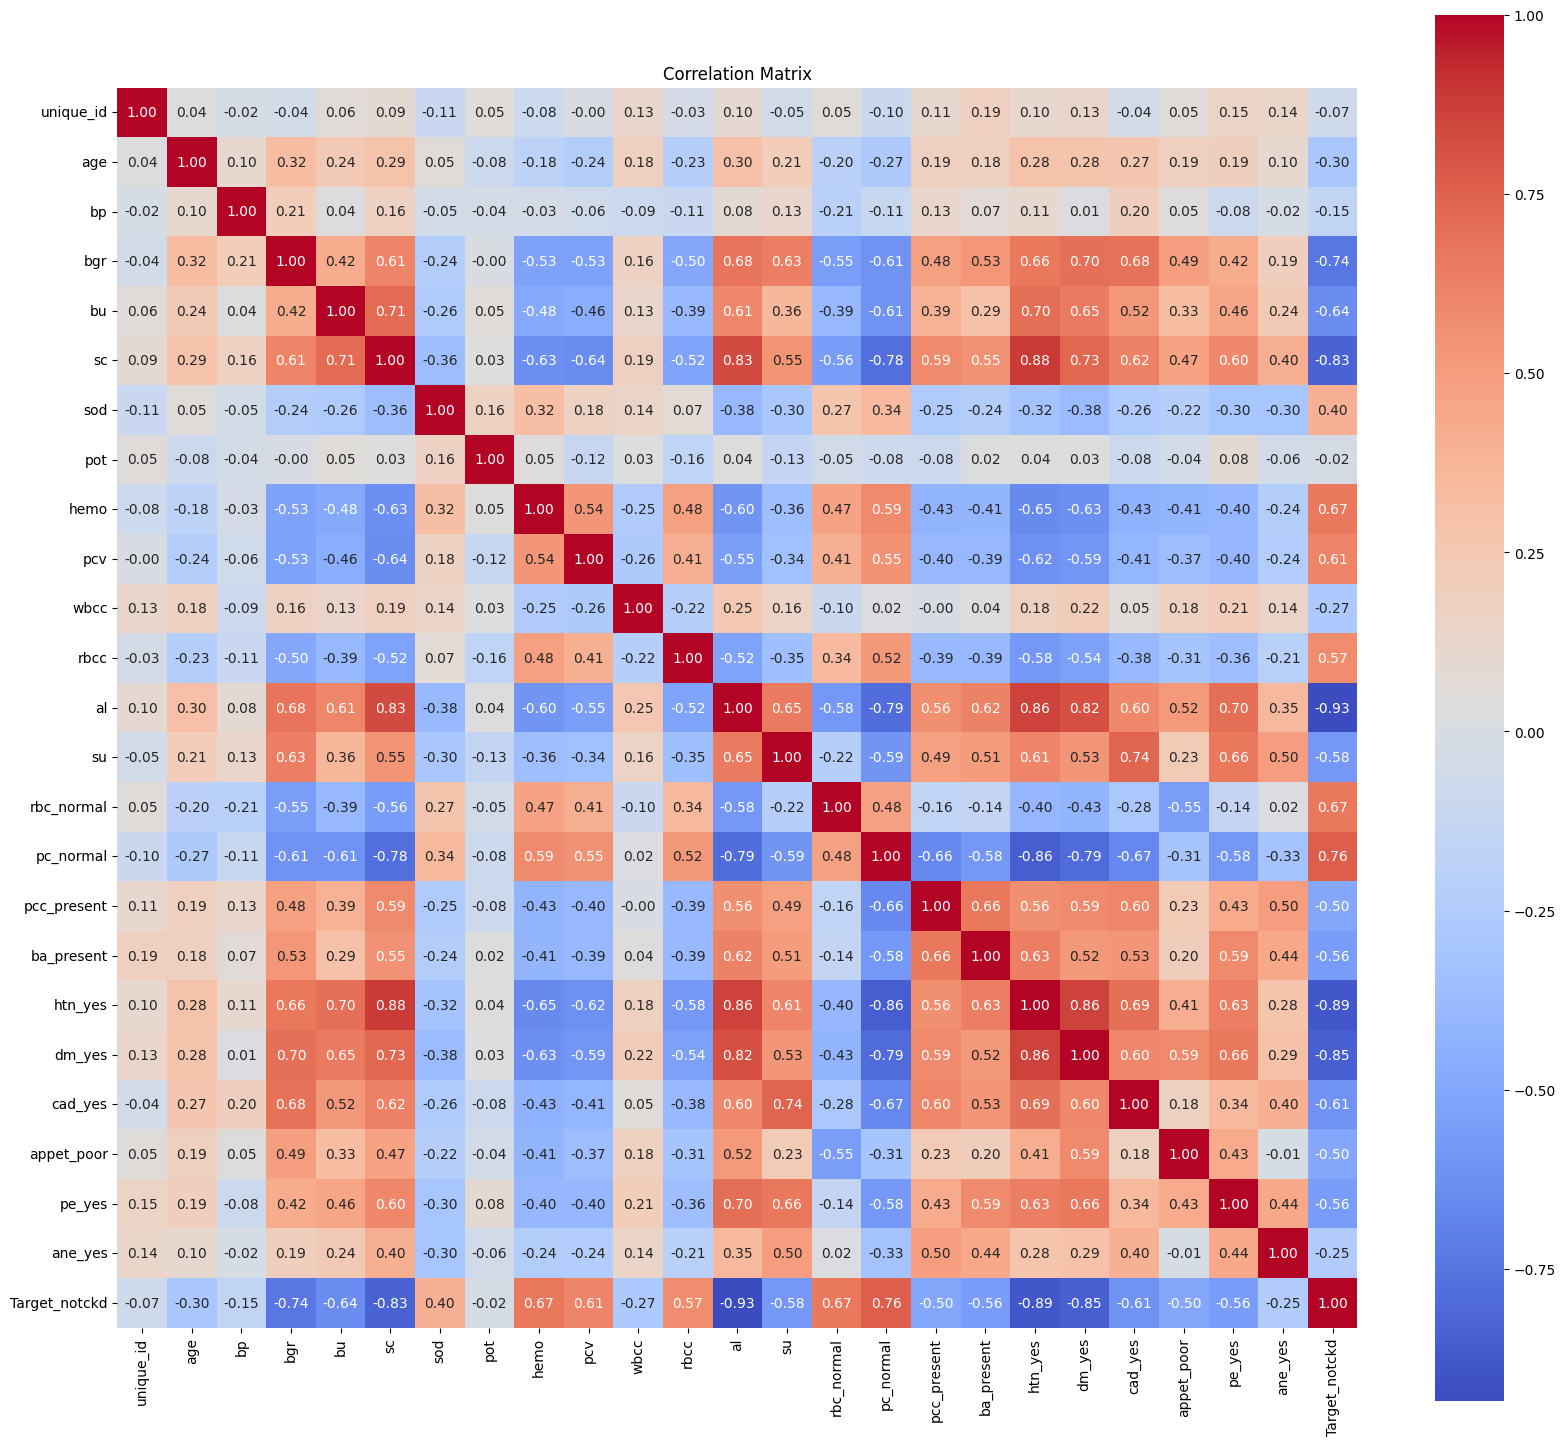

In [16]:
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

In [22]:
#deciding which features to eliminate -- I will keep my threshold at 0.6
threshold = 0.8  # Define your threshold for correlation
to_remove = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:  # Check for high correlation
            colname = correlation_matrix.columns[i]  # Name of the column
            to_remove.append(colname)
to_remove = list(set(to_remove))
print(f"Columns to consider removing due to high correlation: {to_remove}")

Columns to consider removing due to high correlation: ['Target_notckd', 'dm_yes', 'al', 'htn_yes']


In [23]:
#Remove that column
df = df.drop(columns=to_remove)

# Print the dataset
print(df.head(10))

     unique_id       age    bp       bgr        bu        sc       sod  \
105     137148  0.897059  1.00  0.965665  0.606061  0.825397  0.666667   
152     514721  0.647059  0.75  0.253219  0.734848  1.000000  0.366667   
372     532520  0.705882  0.75  0.150215  0.325758  0.301587  0.533333   
363     546225  0.500000  0.00  0.399142  0.621212  0.460317  0.700000   
349     621332  0.691176  0.50  1.000000  0.189394  0.142857  0.066667   
262     397388  0.750000  1.00  0.901288  0.189394  0.444444  0.766667   
288     438182  0.897059  0.50  0.785408  1.000000  0.666667  0.600000   
239     923613  0.764706  0.00  0.725322  0.363636  0.619048  0.566667   
298     955830  0.632353  0.50  0.618026  0.477273  0.555556  0.566667   
228     995177  0.838235  0.25  0.618026  0.651515  0.936508  0.000000   

          pot      hemo       pcv  ...      rbcc   su  rbc_normal  pc_normal  \
105  0.000000  0.011494  0.076923  ...  0.000000  2.0       False      False   
152  0.655172  0.000000  

## Part 3.9: Export the Cleaned Data

Now that you've completed these cleaning steps you should have a pandas dataframe which is much cleaner and ready for modeling. Our final step is to save our work. Export the DataFrame to a two new formats: csv and json.

In [25]:
# Export the dataframe to a new csv file
df.to_csv('cleaned_merged_dataset_chronic_kidney_disease.csv', header=False, index=False)

# Export the dataframe to a new json file
df.to_json('cleaned_merged_dataset_chronic_kidney_disease_data.json', orient = 'split', compression = 'infer', index = 'true')

# Part 4: Data conversions with Large Language Models

One powerful use case of ChatGPT (and other generative language models) is cleaning and transforming data. In some cases, these models can directly manipulate loosely structured data that you provide to them into a standard format. In the other cases, you can often prompt the model to create a conversion or extraction script for you in python or Pandas and then run it on your own. 

In this part of the assignment you will prompt 383GPT to explore these capabilities.

## Part 4.1 GPT Data Manipulation

Take the cleaned dataset that you created in part three and output the top 15 rows of that dataset. Then copy the terminal output, open 383gpt and ask it to convert that output to a markdown table. Paste that markdown table in the cell bellow

In [26]:
print(df.head(15))

     unique_id       age    bp       bgr        bu        sc       sod  \
105     137148  0.897059  1.00  0.965665  0.606061  0.825397  0.666667   
152     514721  0.647059  0.75  0.253219  0.734848  1.000000  0.366667   
372     532520  0.705882  0.75  0.150215  0.325758  0.301587  0.533333   
363     546225  0.500000  0.00  0.399142  0.621212  0.460317  0.700000   
349     621332  0.691176  0.50  1.000000  0.189394  0.142857  0.066667   
262     397388  0.750000  1.00  0.901288  0.189394  0.444444  0.766667   
288     438182  0.897059  0.50  0.785408  1.000000  0.666667  0.600000   
239     923613  0.764706  0.00  0.725322  0.363636  0.619048  0.566667   
298     955830  0.632353  0.50  0.618026  0.477273  0.555556  0.566667   
228     995177  0.838235  0.25  0.618026  0.651515  0.936508  0.000000   
315     843362  0.867647  0.00  0.206009  0.871212  0.777778  0.533333   
314     828592  0.867647  0.25  0.639485  0.545455  0.507937  0.433333   
405     197452  0.647059  0.25  0.6008

### Paste the markdown table here

** Caution: ** while language models can perform data conversions they also can * hallucinate * during this process, particularly for bigger datasets. Reflect on this below, how could you mitigate data conversion hallucinations from LLM conversions?

| unique_id |     age |     bp |      bgr |      bu |        sc |       sod |       pot |      hemo |      pcv | ... |       rbcc |   su | rbc_normal | pc_normal |
|-----------|---------|--------|----------|---------|-----------|-----------|-----------|-----------|----------|-----|------------|------|------------|-----------|
|    137148 | 0.897059|  1.00  | 0.965665 | 0.606061| 0.825397  | 0.666667  | 0.000000  | 0.011494  |  0.076923| ... |  0.000000  |  2.0 |    False   |    False  |
|    514721 | 0.647059|  0.75  | 0.253219 | 0.734848| 1.000000  | 0.366667  | 0.655172  | 0.000000  |  0.038462| ... |  0.060606  |  0.0 |    False   |    False  |
|    532520 | 0.705882|  0.75  | 0.150215 | 0.325758| 0.301587  | 0.533333  | 0.793103  | 0.229885  |  0.192308| ... |  0.272727  |  0.0 |    False   |     True  |
|    546225 | 0.500000|  0.00  | 0.399142 | 0.621212| 0.460317  | 0.700000  | 0.379310  | 0.080460  |  0.000000| ... |  0.000000  |  0.0 |     True   |     True  |
|    621332 | 0.691176|  0.50  | 1.000000 | 0.189394| 0.142857  | 0.066667  | 0.206897  | 0.149425  |  0.269231| ... |  0.333333  |  0.0 |    False   |     True  |
|    397388 | 0.750000|  1.00  | 0.901288 | 0.189394| 0.444444  | 0.766667  | 0.206897  | 0.448276  |  0.461538| ... |  0.303030  |  2.0 |     True   |     True  |
|    438182 | 0.897059|  0.50  | 0.785408 | 1.000000| 0.666667  | 0.600000  | 1.000000  | 0.160920  |  0.192308| ... |  0.333333  |  0.0 |    False   |    False  |
|    923613 | 0.764706|  0.00  | 0.725322 | 0.363636| 0.619048  | 0.566667  | 0.379310  | 0.080460  |  0.000000| ... |  0.000000  |  0.0 |     True   |    False  |
|    955830 | 0.632353|  0.50  | 0.618026 | 0.477273| 0.555556  | 0.566667  | 0.206897  | 0.148148  |  0.269231| ... |  0.094741  |  0.0 |    False   |     True  |
|    995177 | 0.838235|  0.25  | 0.618026 | 0.651515| 0.936508  | 0.000000  | 0.793103  | 0.127273  |  0.307692| ... |  0.303030  |  0.0 |    False   |    False  |
|    843362 | 0.867647|  0.00  | 0.206009 | 0.871212| 0.777778  | 0.533333  | 0.379310  | 0.080460  |  0.000000| ... |  0.000000  |  0.0 |    False   |     True  |
|    828592 | 0.867647|  0.25  | 0.639485 | 0.545455| 0.507937  | 0.433333  | 0.379310  | 0.080460  |  0.000000| ... |  0.000000  |  0.0 |    False   |    False  |
|    197452 | 0.647059|  0.25  | 0.600858 | 0.121212| 0.206349  | 0.533333  | 0.000000  | 0.281486  |  0.046154| ... |  0.000000  |  0.0 |    False   |    False  |
|    124304 | 0.838235|  0.25  | 0.832618 | 0.583333| 0.365079  | 0.333333  | 0.000000  | 0.281486  |  0.653846| ... |  0.000000  |  0.0 |    False   |    False  |
|    980291  | 0.735294|  0.25  | 0.223176 | 0.242424| 0.206349  | 0.533333  | 0.800000  | 0.281486  |  0.346154| ... |  0.000000  |  0.0 |    False   |    False  |


## Part 4.2 GPT Pandas Prompting

In this section, you will prompt 383GPT to write pandas code manipulations for you.

After working with this data for awhile, we realized we're starting to forget the meanings of the abbreviated column names. Let's ask 383GPT to fix this for us. First, navigate to the [UCI dataset overview](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease) and copy the abbrevation to name mapping. Then, go to 383GPT and instruct the LLM to provide you with a pandas script to apply this renaming to all the columns of your dataset. Paste that code below and make any adjustments necessary to run it in your notebook.

In [28]:
# Code to rename all the columns in the dataset
import pandas as pd

# Example DataFrame (you should replace this with your actual DataFrame)
# df = pd.read_csv('your_data.csv')  # Load your DataFrame here

# Creating a dictionary for renaming columns
rename_mapping = {
    'age': 'age',
    'bp': 'blood pressure',
    'sg': 'specific gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'red blood cells',
    'pc': 'pus cell',
    'pcc': 'pus cell clumps',
    'ba': 'bacteria',
    'bgr': 'blood glucose random',
    'bu': 'blood urea',
    'sc': 'serum creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed cell volume',
    'wc': 'white blood cell count',
    'rc': 'red blood cell count',
    'htn': 'hypertension',
    'dm': 'diabetes mellitus',
    'cad': 'coronary artery disease',
    'appet': 'appetite',
    'pe': 'pedal edema',
    'ane': 'anemia',
    'class': 'class'
}

# Apply renaming to the DataFrame's columns
df.rename(columns=rename_mapping, inplace=True)

# Print the modified DataFrame's columns to verify the changes
print(df.columns)

Index(['unique_id', 'age', 'blood pressure', 'blood glucose random',
       'blood urea', 'serum creatinine', 'sodium', 'potassium', 'hemoglobin',
       'packed cell volume', 'wbcc', 'rbcc', 'sugar', 'rbc_normal',
       'pc_normal', 'pcc_present', 'ba_present', 'cad_yes', 'appet_poor',
       'pe_yes', 'ane_yes'],
      dtype='object')


## Part 4.3 Augmenting our skills with prompting

In addition, we can also use 383GPT to convert our data manipulation operations between different data manipulation languages and libraries. For example let's prompt 383GPT to convert the following SQL query to a pandas query.

**SQL Query**
```sql
SELECT Target, COUNT(*) AS count
FROM your_table_name
GROUP BY Target;
```

Prompt 383GPT to convert this to a pandas query. Run this query below, then describe what it does. (If you're not familiar with SQL that is okay you need to only comment on the final resulting output.)

In [31]:
# Converted SQL to Pandas code
#import pandas as pd

# Assuming df is your DataFrame
# df = pd.read_csv('your_data.csv')  # Load your DataFrame here

# Group by 'Target' and count the occurrences
result = df.groupby('sugar').size().reset_index(name='count')

# Print the result
print(result)

   sugar  count
0    0.0    158
1    1.0      3
2    2.0      2
3    3.0      1
4    4.0      1


*Describe what the above code does here*

The above code, exactly like a sql query, groups the dataset by the target column (i changed it to sugar here because target was one of the columns removed based on the ouptut from the correlation matrix). Then it uses the count function (size in pandas) to count the number of occurrences for each group. Then it uses reset_index to convert is back to dataframe and name the column as count. The result is printed.

383Gpt also gave me an alternative to using count in my pandas function instead of count:

In [35]:
result = df.groupby('sugar')['sugar'].count().reset_index(name='count')